# Spatial Analysis & Choropleth Maps

**Author:** Yi

**Description:** In this notebook, we produce choropleth maps for Focus Area 2 (Descriptive Spatial Analysis and Maps).  

**AI Statement:** AI were used in the this notebook to assist with visualization formatting and parameter tuning. AI was also used for learning geopandas library. All analytical decisions, interpretations, and final code were written by the author.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import geopandas as gpd
import requests, io
from adjustText import adjust_text
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'

In [ ]:
# Load merged dataset 
df = pd.read_csv('final_merged_5e_311_cps_acs.csv')
print(f'Dataset: {df.shape[0]} community areas × {df.shape[1]} variables')

# Log-transform 311 response time (right-skewed, as noted in EDA)
df['log_311_response'] = np.log10(df['sr_avg_median_ttc_hours'])

print('\nKey variable summaries:')
key_vars = ['sr_avg_median_ttc_hours', 'log_311_response',
            'cps_student_attendance', 'avg_environment_score', 'acs_poverty_rate']
print(df[key_vars].describe().round(2))

Dataset: 77 community areas × 39 variables

Key variable summaries:
       sr_avg_median_ttc_hours  log_311_response  cps_student_attendance  \
count                    77.00             77.00                   77.00   
mean                    278.99              2.16                   91.35   
std                     723.55              0.41                    1.18   
min                      21.86              1.34                   88.36   
25%                      75.51              1.88                   90.48   
50%                     129.01              2.11                   91.29   
75%                     255.64              2.41                   92.27   
max                    6327.33              3.80                   93.84   

       avg_environment_score  acs_poverty_rate  
count                  76.00             77.00  
mean                   49.62              0.19  
std                     6.51              0.11  
min                    30.88              0.05  
25

In [ ]:
# Load Chicago Community Area shapefile 

# Download GeoJSON using requests (geopandas can't stream this URL directly)
url = 'https://data.cityofchicago.org/resource/igwz-8jzy.geojson'
response = requests.get(url, timeout=30)
response.raise_for_status()

gdf = gpd.read_file(io.BytesIO(response.content))

print('Shapefile columns:', gdf.columns.tolist())
print('CRS:', gdf.crs)
print('Shape:', gdf.shape)

Shapefile columns: ['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len', 'geometry']
CRS: EPSG:4326
Shape: (77, 6)


In [ ]:
# Merge shapefile with our data 
# The shapefile uses 'area_numbe' (string) for community area numbers
gdf['community_area'] = gdf['area_numbe'].astype(int)

gdf_merged = gdf.merge(df, on='community_area', how='left')
print(f'Merged GeoDataFrame: {gdf_merged.shape[0]} rows')
print(f'Missing after merge: {gdf_merged["cps_student_attendance"].isna().sum()} rows')

Merged GeoDataFrame: 77 rows
Missing after merge: 0 rows


In [ ]:
# Helper: identify top/bottom outliers for annotation 
def get_outlier_labels(gdf_merged, col, n=5, worst='low'):
    """Return community area names for the n worst-performing areas."""
    sub = gdf_merged[['community_area_name', col, 'geometry']].dropna()
    if worst == 'low':
        return sub.nsmallest(n, col)
    else:
        return sub.nlargest(n, col)

def annotate_areas(ax, rows, col, fontsize=7, color='black'):
    """Annotate community area centroids — auto-adjusts to avoid overlaps."""
    texts = []
    for _, row in rows.iterrows():
        centroid = row['geometry'].centroid
        t = ax.text(
            centroid.x, centroid.y,
            row['community_area_name'].title(),
            fontsize=fontsize,
            ha='center',
            color=color,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
        texts.append(t)
    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.5, 1.5),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
    )

## Map 1: Side-by-Side — 311 Response Time vs. Student Attendance
This is the core comparison map for the presentation: do areas with slow 311 response also have lower attendance?

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


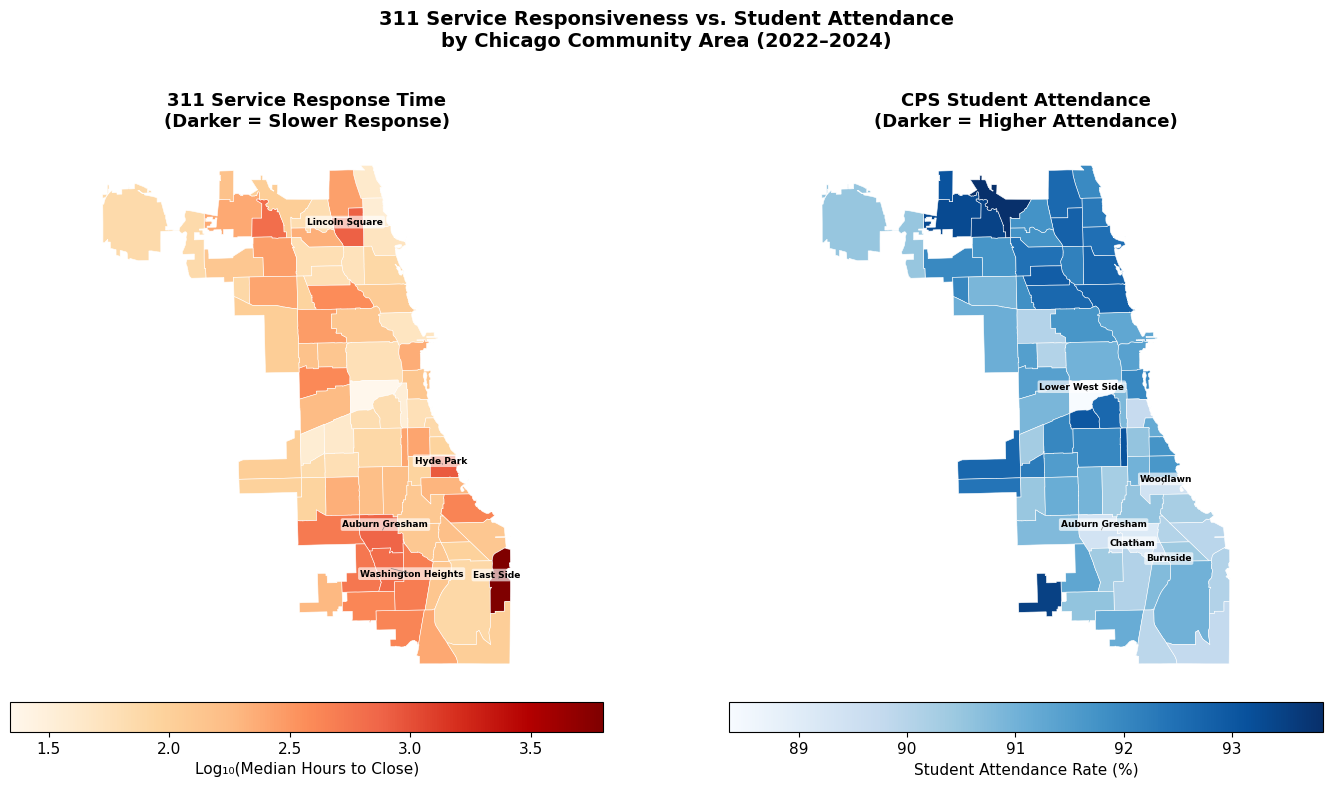

Saved: map_01_311_vs_attendance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel A: 311 Log Response Time (high = worse) 
ax1 = axes[0]
gdf_merged.plot(
    column='log_311_response',
    cmap='OrRd',          
    linewidth=0.4,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Log₁₀(Median Hours to Close)',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax1
)
# Annotate 5 slowest areas
slowest = get_outlier_labels(gdf_merged, 'log_311_response', n=5, worst='high')
annotate_areas(ax1, slowest, 'log_311_response', fontsize=6.5)

ax1.set_title('311 Service Response Time\n(Darker = Slower Response)', fontsize=13, fontweight='bold', pad=10)
ax1.axis('off')

# Panel B: Student Attendance (low = worse)
ax2 = axes[1]
gdf_merged.plot(
    column='cps_student_attendance',
    cmap='Blues',          # darker = higher attendance (better)
    linewidth=0.4,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Student Attendance Rate (%)',
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax2
)
# Annotate 5 lowest attendance areas
lowest_att = get_outlier_labels(gdf_merged, 'cps_student_attendance', n=5, worst='low')
annotate_areas(ax2, lowest_att, 'cps_student_attendance', fontsize=6.5)

ax2.set_title('CPS Student Attendance\n(Darker = Higher Attendance)', fontsize=13, fontweight='bold', pad=10)
ax2.axis('off')

plt.suptitle(
    '311 Service Responsiveness vs. Student Attendance\nby Chicago Community Area (2022–2024)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('map_01_311_vs_attendance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: map_01_311_vs_attendance.png')

## Map 2: Four-Panel Overview
All four key variables side-by-side: 311 response, school climate (Environment score), student attendance, poverty rate.

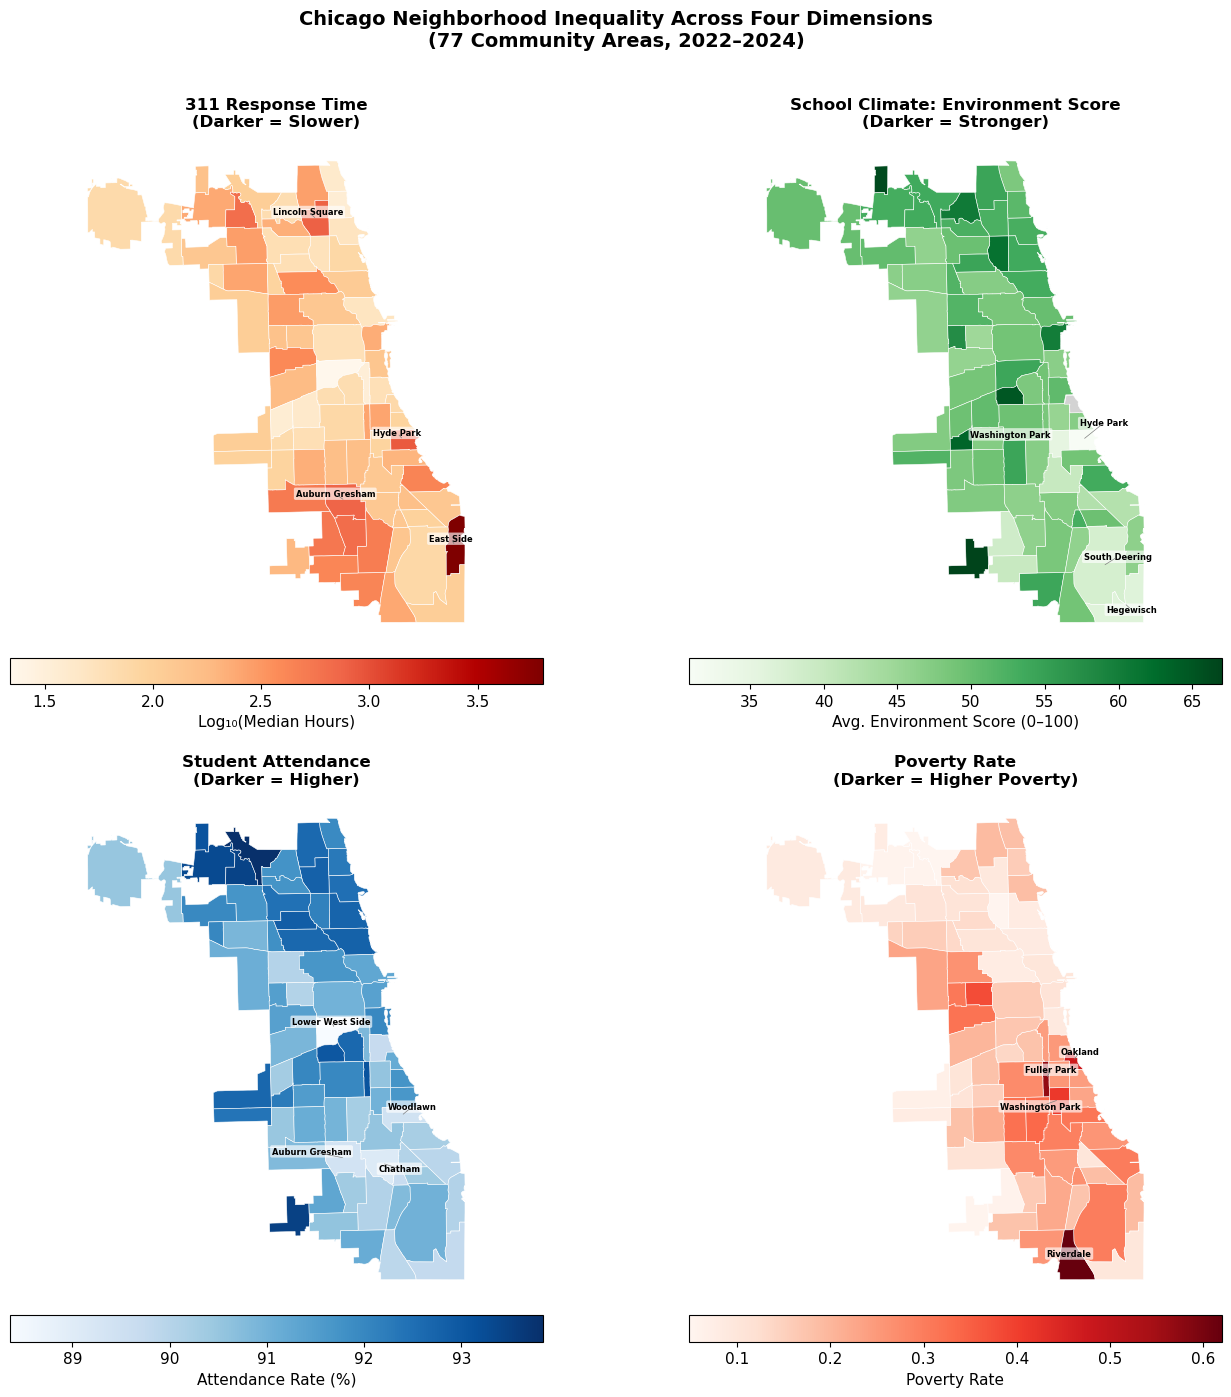

Saved: map_02_four_panel_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

panels = [
    {
        'col': 'log_311_response',
        'cmap': 'OrRd',
        'title': '311 Response Time\n(Darker = Slower)',
        'legend_label': 'Log₁₀(Median Hours)',
        'worst': 'high',
        'n': 4
    },
    {
        'col': 'avg_environment_score',
        'cmap': 'Greens',
        'title': 'School Climate: Environment Score\n(Darker = Stronger)',
        'legend_label': 'Avg. Environment Score (0–100)',
        'worst': 'low',
        'n': 4
    },
    {
        'col': 'cps_student_attendance',
        'cmap': 'Blues',
        'title': 'Student Attendance\n(Darker = Higher)',
        'legend_label': 'Attendance Rate (%)',
        'worst': 'low',
        'n': 4
    },
    {
        'col': 'acs_poverty_rate',
        'cmap': 'Reds',
        'title': 'Poverty Rate\n(Darker = Higher Poverty)',
        'legend_label': 'Poverty Rate',
        'worst': 'high',
        'n': 4
    },
]

for ax, panel in zip(axes.flatten(), panels):
    gdf_merged.plot(
        column=panel['col'],
        cmap=panel['cmap'],
        linewidth=0.4,
        edgecolor='white',
        legend=True,
        legend_kwds={
            'label': panel['legend_label'],
            'orientation': 'horizontal',
            'shrink': 0.6,
            'pad': 0.02
        },
        missing_kwds={'color': 'lightgrey'},
        ax=ax
    )
    outliers = get_outlier_labels(gdf_merged, panel['col'], n=panel['n'], worst=panel['worst'])
    annotate_areas(ax, outliers, panel['col'], fontsize=6)
    ax.set_title(panel['title'], fontsize=12, fontweight='bold', pad=8)
    ax.axis('off')

plt.suptitle(
    'Chicago Neighborhood Inequality Across Four Dimensions\n(77 Community Areas, 2022–2024)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('map_02_four_panel_overview.png', dpi=200, bbox_inches='tight')
plt.show()

## Map 3: Bivariate Choropleth — 311 Response Time × Student Attendance
Combines two variables in a single map. Areas in the darkest category (slow 311 AND low attendance) are highlighted as potential 'double disadvantage' zones.

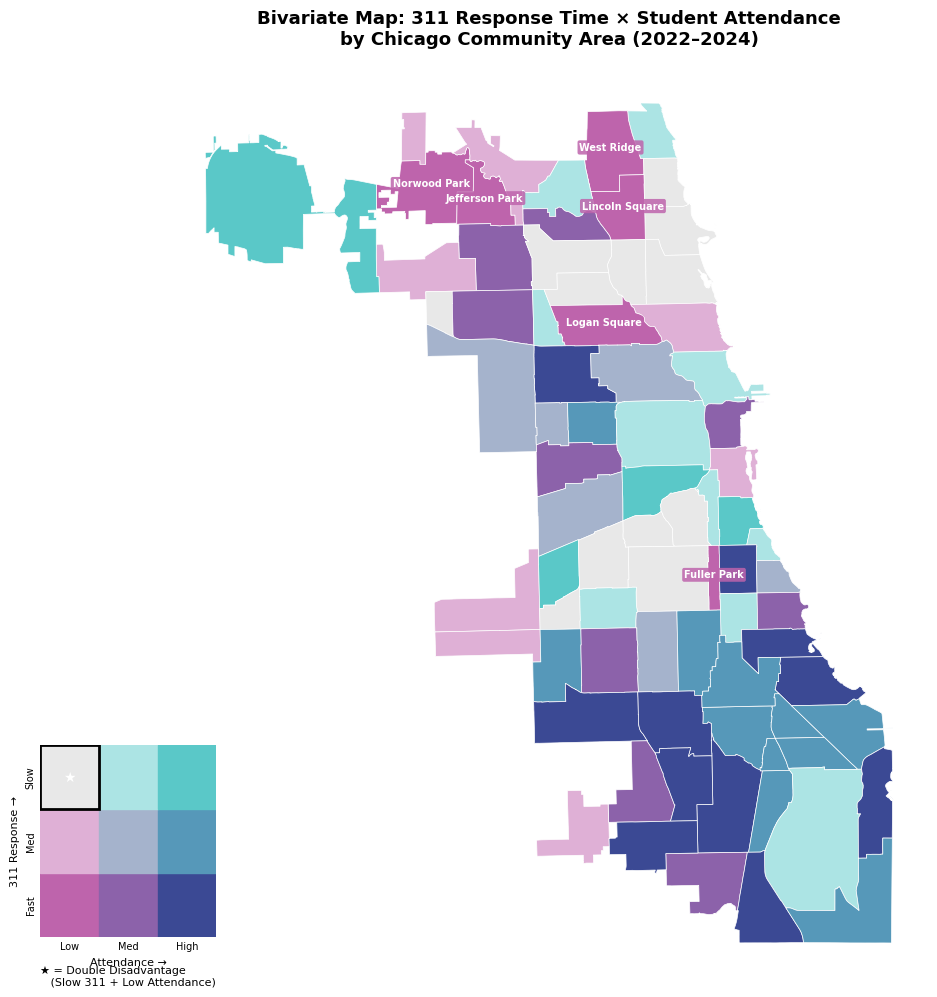

In [ ]:
#  Bivariate choropleth setup 
gdf_merged['bin_311'] = pd.qcut(
    gdf_merged['log_311_response'], q=3, labels=[0, 1, 2]
).astype(float)

gdf_merged['bin_att'] = pd.qcut(
    gdf_merged['cps_student_attendance'], q=3, labels=[2, 1, 0]
).astype(float)

gdf_merged['bivar_class'] = (
    gdf_merged['bin_311'].fillna(-1) * 3 + gdf_merged['bin_att'].fillna(-1)
).where(gdf_merged['bin_311'].notna() & gdf_merged['bin_att'].notna(), other=np.nan)

bivar_colors = {
    0.0: '#e8e8e8', 1.0: '#ace4e4', 2.0: '#5ac8c8',
    3.0: '#dfb0d6', 4.0: '#a5b3cc', 5.0: '#5698b9',
    6.0: '#be64ac', 7.0: '#8c62aa', 8.0: '#3b4994',
}

gdf_merged['bivar_color'] = gdf_merged['bivar_class'].map(bivar_colors).fillna('#d3d3d3')

#  Plot 
fig, ax = plt.subplots(figsize=(11, 12))

gdf_merged.plot(color=gdf_merged['bivar_color'], linewidth=0.5, edgecolor='white', ax=ax)

double_dis = gdf_merged[gdf_merged['bivar_class'] == 6.0]
for _, row in double_dis.iterrows():
    centroid = row['geometry'].centroid
    ax.annotate(
        row['community_area_name'].title(),
        xy=(centroid.x, centroid.y),
        fontsize=7, ha='center', color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='#be64ac', alpha=0.85, ec='none')
    )

ax.set_title(
    'Bivariate Map: 311 Response Time × Student Attendance\nby Chicago Community Area (2022–2024)',
    fontsize=13, fontweight='bold', pad=12
)
ax.axis('off')

# ── Legend (3×3 grid inset) ───────────────────────────────────────────────────
legend_ax = fig.add_axes([0.05, 0.15, 0.16, 0.16])  # raised bottom, slightly smaller
legend_matrix = np.array([
    [bivar_colors[6.0], bivar_colors[7.0], bivar_colors[8.0]],  # slow 311 (top row)
    [bivar_colors[3.0], bivar_colors[4.0], bivar_colors[5.0]],  # med 311
    [bivar_colors[0.0], bivar_colors[1.0], bivar_colors[2.0]],  # fast 311 (bottom row)
])
for r in range(3):
    for c in range(3):
        legend_ax.add_patch(mpatches.Rectangle((c, r), 1, 1, color=legend_matrix[r, c]))

legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)

# Centered tick labels — no corner collision
legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(['Low', 'Med', 'High'], fontsize=7)
legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_yticklabels(['Fast', 'Med', 'Slow'], fontsize=7, rotation=90, va='center')

legend_ax.set_xlabel('Attendance →', fontsize=8, labelpad=4)
legend_ax.set_ylabel('311 Response →', fontsize=8, labelpad=4)
legend_ax.tick_params(length=0)
for spine in legend_ax.spines.values():
    spine.set_visible(False)

# Highlight double disadvantage cell
legend_ax.add_patch(
    mpatches.Rectangle((0, 2), 1, 1, fill=False, edgecolor='black', linewidth=2)
)
legend_ax.text(0.5, 2.5, '★', ha='center', va='center', fontsize=10, color='white')

# Annotation text safely below the legend box (bottom=0.15, so place at 0.11)
fig.text(0.05, 0.11, '★ = Double Disadvantage\n   (Slow 311 + Low Attendance)', fontsize=8)

plt.savefig('map_03_bivariate_311_attendance.png', dpi=200, bbox_inches='tight')
plt.show()